In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

In [2]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

model = joblib.load('../models/fraud_model_tuned.joblib')

print("Loaded!")

Loaded!


In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (56962, 30)


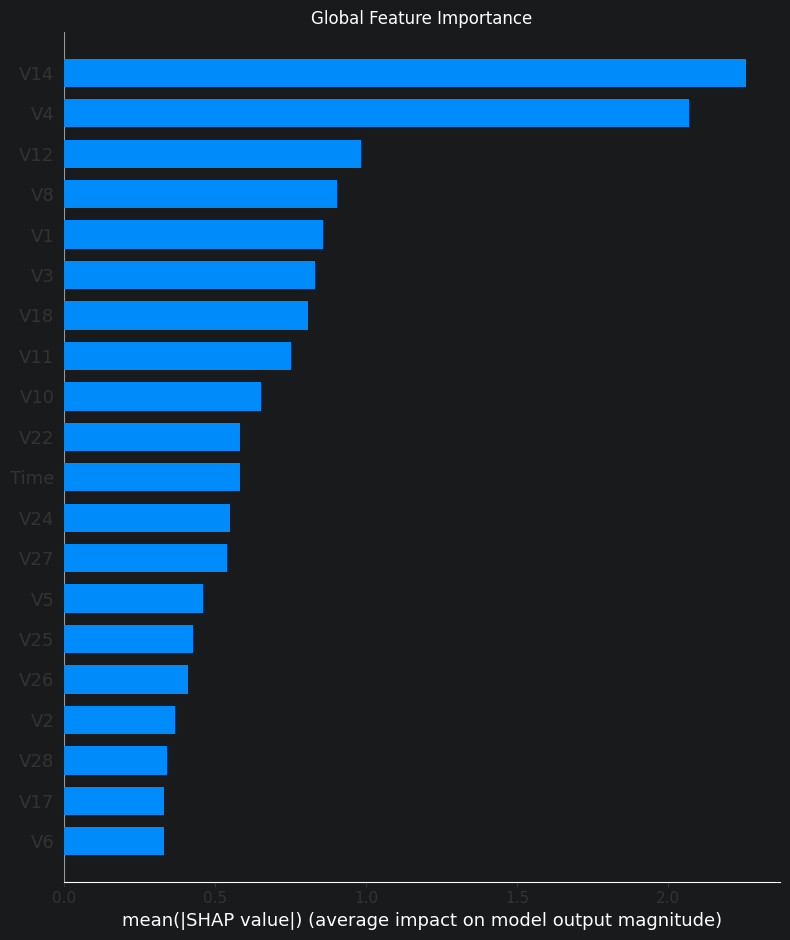

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance')
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png')
plt.show()

V14 and V4 are the strongest fraud indicators in the model, contributing significantly more than any other feature. Time of transaction also plays a notable role, suggesting fraudulent activity clusters at certain periods.



Explaining transaction index: 840
Actual label: FRAUD


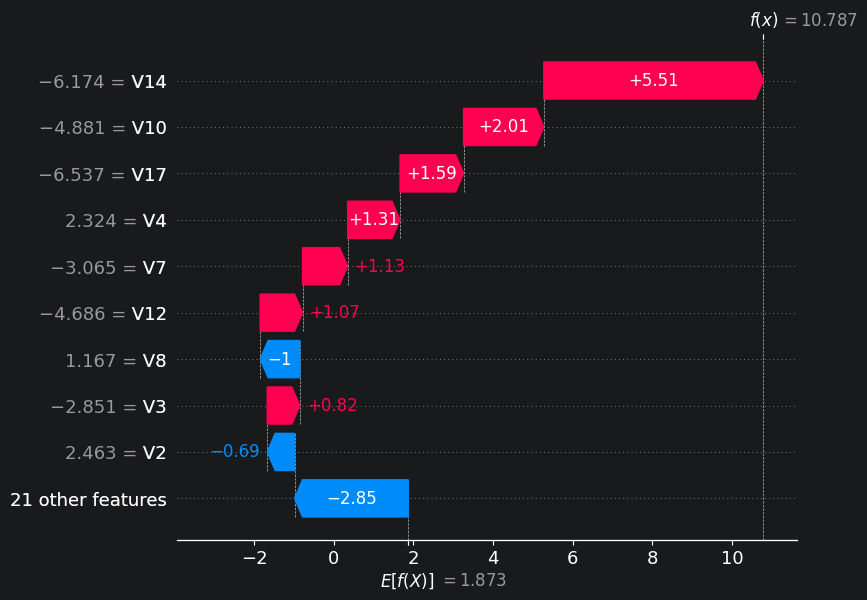

In [5]:
# Find a fraud transaction
fraud_indices = np.where(y_test == 1)[0]
fraud_idx = fraud_indices[0]

print(f"Explaining transaction index: {fraud_idx}")
print(f"Actual label: FRAUD")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[fraud_idx],
        feature_names=X_test.columns.tolist()
    )
)